# Redes Neuronales Multicapa Con Tensorflow: Clasificación Y Regresión

**Sesión:** Aprendizaje Supervisado Con TensorFlow  
**Fecha:** 2025-09-30

Este Cuaderno Usa Tensorflow/Keras Para Entrenar Modelos MLP En Tareas Reales De Clasificación Y Regresión. Incluye Métricas, Gráficas Y Ejercicios Para Resolver En Clase.

## Requisitos Y Entorno

Usaremos Tensorflow/Keras, NumPy, Pandas, Matplotlib Y Scikit-Learn Para Preprocesamiento Y Métricas.

In [3]:
# Versiones Básicas (Solo Referencia)
import sys, numpy, pandas, matplotlib, sklearn
import tensorflow as tf

print("Python:", sys.version.split()[0])
print("TensorFlow:", tf.__version__)
print("NumPy:", numpy.__version__)
print("Pandas:", pandas.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Scikit-Learn:", sklearn.__version__)

2026-03-10 10:27:46.938202: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


KeyboardInterrupt: 

## Objetivos De Aprendizaje

1. Entender La Arquitectura De Un MLP Para Tareas Supervisadas Con Tensorflow/Keras.
2. Entrenar Un Modelo De Clasificación Binaria Con El Dataset Breast_Cancer.
3. Entrenar Un Modelo De Regresión Con El Dataset California Housing.
4. Evaluar Con Métricas Apropiadas (Accuracy, ROC-AUC, MSE, MAE, R²).
5. Ajustar Hiperparámetros Y Analizar Efectos En Bias/Variance.
6. Resolver Ejercicios Prácticos En Equipo.

## Parte 1 · Clasificación Binaria Con Tensorflow/Keras (Dataset: Breast_Cancer)

Flujo: Carga De Datos, Escalamiento, Definición Del Modelo MLP, Entrenamiento, Métricas (Accuracy, ROC-AUC) Y Gráficas.

In [ ]:
# Cargar Y Preparar Datos De Clasificación
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

data = load_breast_cancer()
X = data.data
y = data.target

print("Dataset shape:", X.shape)
print("Classes:", np.unique(y))

# Escalamiento
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Class distribution:", np.bincount(y_train))

In [ ]:
# Definir Y Compilar Un MLP Con Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("Features:", X_train.shape[1])

model_cls = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model_cls.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_cls.summary()

In [ ]:
# Entrenar El Modelo
history_cls = model_cls.fit(
    X_train, y_train, 
    validation_data=(X_test, y_test),
    epochs=40,
    batch_size=32,
    verbose=1
)

In [ ]:
# Evaluar Y Reportar Métricas Clave
from sklearn.metrics import classification_report, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

loss, acc = model_cls.evaluate(X_test, y_test, verbose=0)
print("Accuracy (Test):", round(acc, 4))

# Probabilidades Para ROC-AUC
y_prob = model_cls.predict(X_test, verbose=0).ravel()
auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC (Test):", round(auc, 4))

# Curvas De Entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history_cls.history["loss"], label="Train Loss")
axes[0].plot(history_cls.history["val_loss"], label="Val Loss")
axes[0].set_title("Loss over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

# Accuracy
axes[1].plot(history_cls.history["accuracy"], label="Train Accuracy")
axes[1].plot(history_cls.history["val_accuracy"], label="Val Accuracy")
axes[1].set_title("Accuracy over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

# ROC Curve
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("ROC Curve")
plt.show()

### Ejercicio 1 · Arquitectura Y Regularización

Modifica La Arquitectura (Unidades Y Número De Capas) Y La Regularización (Kernel_Regularizer L2 O Dropout). Registra Cambios En Accuracy Y ROC-AUC.

In [ ]:
# Ejercicio 1: Punto De Partida Con L2 Y Dropout
from tensorflow.keras import regularizers

model_exp = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(1e-3)),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(1e-3)),
    layers.Dropout(0.2),
    layers.Dense(1, activation="sigmoid")
])

model_exp.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_exp = model_exp.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=60,
    batch_size=32,
    verbose=1
)

# Evaluar
loss_exp, acc_exp = model_exp.evaluate(X_test, y_test, verbose=0)
print("Accuracy (Val Última Época):", round(acc_exp, 4))

y_prob_exp = model_exp.predict(X_test, verbose=0).ravel()
auc_exp = roc_auc_score(y_test, y_prob_exp)
print("ROC-AUC:", round(auc_exp, 4))

### Ejercicio 2 · Ajuste De Umbral

Explora Umbrales Entre 0.3 Y 0.7 Para Convertir Probabilidades En Etiquetas. Grafica F1 Versus Umbral Y Elige El Mejor Compromiso.

In [ ]:
# Ejercicio 2: Barrido De Umbral Para F1
import numpy as np
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

probs = model_cls.predict(X_test, verbose=0).ravel()
umbral_list = np.linspace(0.3, 0.7, 21)
f1_vals = []

for t in umbral_list:
    pred_t = (probs >= t).astype(int)
    f1_vals.append(f1_score(y_test, pred_t))

plt.figure()
plt.plot(umbral_list, f1_vals, marker='o')
plt.xlabel("Umbral")
plt.ylabel("F1 Score")
plt.title("F1 Score vs Umbral")
plt.grid(True)
plt.show()

best_idx = np.argmax(f1_vals)
print("Mejor Umbral:", round(umbral_list[best_idx], 3))
print("Mejor F1:", round(f1_vals[best_idx], 4))

## Parte 2 · Regresión Con Tensorflow/Keras (Dataset: California Housing)

Flujo: Carga, Escalamiento, MLP Regresor, Entrenamiento, Métricas MSE/MAE/R², Gráficos De Predicción Vs Valor Real Y Residuos.

In [ ]:
# Cargar Y Preparar Datos De Regresión
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

ch = fetch_california_housing(as_frame=True)
Xr = ch.data.values
yr = ch.target.values

scaler_r = StandardScaler()
Xr = scaler_r.fit_transform(Xr)

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    Xr, yr, test_size=0.2, random_state=42
)

print("Xr_train shape:", Xr_train.shape)
print("Xr_test shape:", Xr_test.shape)

Xr_train shape: (16512, 8)
Xr_test shape: (4128, 8)


In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


2026-03-10 10:30:40.416151: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [5]:
# Definir Y Compilar MLP Para Regresión
model_reg = keras.Sequential([
    layers.Input(shape=(Xr_train.shape[1],)),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(1)
])

model_reg.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mse", "mae"]
)

model_reg.summary()

2026-03-10 10:30:51.689866: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,473 (37.00 KB)

 Trainable params: 9,473 (37.00 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Entrenar
history_reg = model_reg.fit(
    Xr_train, yr_train,
    validation_data=(Xr_test, yr_test),
    epochs=50,
    batch_size=64,
    verbose=1
)

Epoch 1/50
258/258 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - loss: 0.8660 - mae: 0.6337 - mse: 0.8660 - val_loss: 0.4417 - val_mae: 0.4672 - val_mse: 0.4417
Epoch 2/50
258/258 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.4126 - mae: 0.4518 - mse: 0.4126 - val_loss: 0.3923 - val_mae: 0.4361 - val_mse: 0.3923
Epoch 3/50
258/258 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.3774 - mae: 0.4342 - mse: 0.3774 - val_loss: 0.3696 - val_mae: 0.4316 - val_mse: 0.3696
Epoch 4/50
258/258 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.3836 - mae: 0.4281 - mse: 0.3836 - val_loss: 0.3615 - val_mae: 0.4292 - val_mse: 0.3615
Epoch 5/50
258/258 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.3544 - mae: 0.4195 - mse: 0.3544 - val_loss: 0.4792 - val_mae: 0.4260 - val_mse: 0.4792
Epoch 6/50
258/258 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.3692 - mae: 0.4150 - mse: 0.3692 - val_loss: 0.3358 - val_mae: 0.4056 - val_mse: 0.3358
Epoch 7/50
258/258 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.3271 - mae: 0.4003 - mse: 0.327

MSE: 0.2694
MAE: 0.3559
R²: 0.7944


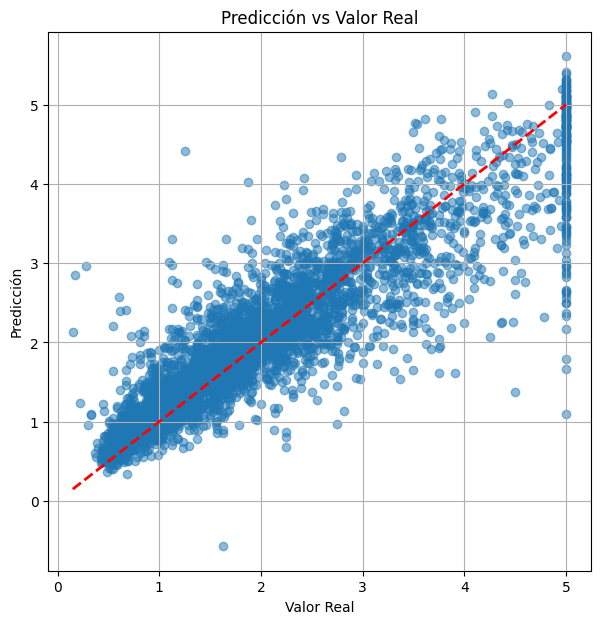

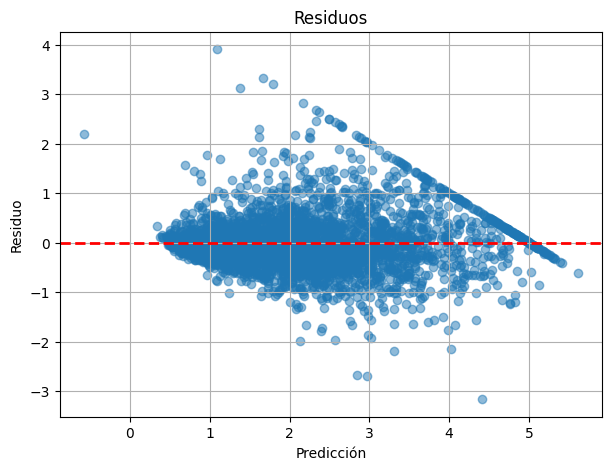

In [7]:
# Métricas Finales Y Gráficas
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

yr_pred = model_reg.predict(Xr_test, verbose=0).ravel()

mse = mean_squared_error(yr_test, yr_pred)
mae = mean_absolute_error(yr_test, yr_pred)
r2 = r2_score(yr_test, yr_pred)

print("MSE:", round(mse, 4))
print("MAE:", round(mae, 4))
print("R²:", round(r2, 4))

# Predicciones vs Real
plt.figure(figsize=(7, 7))
plt.scatter(yr_test, yr_pred, alpha=0.5)
plt.plot([yr_test.min(), yr_test.max()], [yr_test.min(), yr_test.max()], 'r--', lw=2)
plt.xlabel("Valor Real")
plt.ylabel("Predicción")
plt.title("Predicción vs Valor Real")
plt.grid(True)
plt.show()

# Residuos
residuos = yr_test - yr_pred
plt.figure(figsize=(7, 5))
plt.scatter(yr_pred, residuos, alpha=0.5)
plt.axhline(0, color='r', linestyle='--', lw=2)
plt.xlabel("Predicción")
plt.ylabel("Residuo")
plt.title("Residuos")
plt.grid(True)
plt.show()

### Ejercicio 3 · Regularización Y Arquitectura

Añade Capas Con Dropout O L2, Cambia El Tamaño De Las Capas, Y Compara MSE/MAE/R². Reporta Qué Configuración Logra Mejor Generalización.

In [ ]:
# Ejercicio 3: Plantilla Con L2 Y Dropout
from tensorflow.keras import regularizers

model_reg_exp = keras.Sequential([
    layers.Input(shape=(Xr_train.shape[1],)),
    layers.Dense(256, activation="relu", kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dropout(0.2),
    layers.BatchNormalization(),
    layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dense(1)
])

model_reg_exp.compile(optimizer="adam", loss="mse", metrics=["mse", "mae"])

hist_reg_exp = model_reg_exp.fit(
    Xr_train, yr_train,
    validation_data=(Xr_test, yr_test),
    epochs=50,
    batch_size=64,
    verbose=1
)

# Evaluar
yr_pred_exp = model_reg_exp.predict(Xr_test, verbose=0).ravel()
print("MSE (Exp):", round(mean_squared_error(yr_test, yr_pred_exp), 4))
print("MAE (Exp):", round(mean_absolute_error(yr_test, yr_pred_exp), 4))
print("R² (Exp):", round(r2_score(yr_test, yr_pred_exp), 4))

It is a good idea to have both MSE and MAE as you might get a result of an error to 0 but that doesn't necessarily mean that your estimation was perfect, but that your errors were symmetric. 

## Parte 3 · Búsqueda Rápida De Hiperparámetros (Manual)

Prueba Variar Learning Rate, Batch Size Y Arquitectura. Usa Un Ciclo Para Registrar Métricas Y Compararlas.

In [ ]:
# Búsqueda Manual Sencilla De Hiperparámetros En Clasificación (GPU)
import itertools
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Detectar GPU y preparar dispositivo de entrenamiento
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    device_name = "/GPU:0"
else:
    device_name = "/CPU:0"

print(f"Entrenando con: {device_name}")

def build_cls_model(lr=1e-3, units=(64, 32)):
    m = keras.Sequential([
        layers.Input(shape=(X_train.shape[1],)),
        layers.Dense(units[0], activation="relu"),
        layers.Dense(units[1], activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ])
    opt = keras.optimizers.Adam(learning_rate=lr)
    m.compile(optimizer=opt, loss="binary_crossentropy", metrics=["accuracy"])
    return m

# Grid simple
lr_vals = [1e-3, 5e-4]
units_vals = [(64, 32), (128, 64)]

results = []
for lr, units in itertools.product(lr_vals, units_vals):
    print(f"\nTesting lr={lr}, units={units}")
    keras.backend.clear_session()
    with tf.device(device_name):
        model = build_cls_model(lr=lr, units=units)
        hist = model.fit(
            X_train, y_train,
            validation_data=(X_test, y_test),
            epochs=20,
            batch_size=32,
            verbose=0
        )
    val_acc = max(hist.history["val_accuracy"])
    results.append({"lr": lr, "units": units, "val_acc": val_acc})
    print(f"  Val Accuracy: {val_acc:.4f}")

# Mejor combinación
best = max(results, key=lambda x: x["val_acc"])
print(f"\nMejor config: lr={best['lr']}, units={best['units']}, val_acc={best['val_acc']:.4f}")

## Retos En Equipos (10 Minutos Por Equipo)

1. **Selección De Atributos + MLP En Breast_Cancer**: Prueba `VarianceThreshold` O `SelectKBest` Antes Del Modelo, Reporta Accuracy Y ROC-AUC.
2. **Ajuste De Umbral**: Usa La Curva F1 Versus Umbral Para Elegir Un Umbral Óptimo Y Justifica Tu Decisión.
3. **Regresión Con California Housing**: Activa EarlyStopping Y Compara Con Y Sin Regularización L2.

## Cierre

Documenta Tus Hallazgos: Sensibilidad Del MLP A La Escala, Arquitectura, Regularización Y Tasa De Aprendizaje.

In [ ]:
# Redes Neuronales Multicapa Con Tensorflow: Clasificación Y Regresión

**Sesión:** Aprendizaje Supervisado Con TensorFlow  
**Fecha:** 2025-09-30

Este Cuaderno Usa Tensorflow/Keras Para Entrenar Modelos MLP En Tareas Reales De Clasificación Y Regresión. Incluye Métricas, Gráficas Y Ejercicios Para Resolver En Clase.